In [26]:
%load_ext autoreload
%autoreload 2
%cd ~/code/entityrepresentations/

/home/morand/code/entityrepresentations


/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [27]:
import transformers
import transformer_lens as tl 
from transformer_lens import HookedTransformer, patching
from importlib import reload
import torch, os, gc, sys, pathlib
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tikzplotlib      # need matplotlib<3.6

#our own code
import utils 
from LabelExtractor import eval_model, infer_entities
from processResults import *



## Parameters

In [28]:
model_name = "gpt2-small" # 117M ok
model_name = "pythia-2.8b"#ok !
model_name = "mistralai/Mistral-7B-v0.1" # ok JZ a100 8cpus | 
model_name = "gpt2-large" # 774M ok
model_name = "gpt2-medium" # 302M ok
model_name = "gpt2-xl" # 1.5B ok
model_name = "phi-1_5"  # 1.5B ok
model_name = "phi-2" # 2,5B ok 12cpus nope, gpu 24cpus ok

dataset_name= "WebNLG"
dataset_name= "TACRED"
dataset_name= "CoNLL2003"

dtype = torch.float32
dtype = torch.bfloat16

with_context = True
with_context = False

In [29]:
xp_path = pathlib.Path.home() / "experiments_JeanZay" # load results
xp_paths= os.listdir(xp_path / "jobs")      #get all experiments directories
jobs_path = xp_path / "jobs" / xp_paths[0]
results = loadResults(jobs_path)            #get jobs
results = results[(results["model_name"]==model_name) &
                  (results["dataset_name"]==dataset_name) &
                  (results["with_context"]==with_context) ]
print(f"Loaded {len(results)} results")

#get jobs for linear filters
xp_lin = 'labelextractor.learnlinearfilter'
results_linear = loadResults(xp_path / "jobs" / xp_lin)

100%|█████████████████████████████████████████████████████████████████████████████████████████| 2010/2010 [00:07<00:00, 257.84it/s]


Loaded 363 results


100%|███████████████████████████████████████████████████████████████████████████████████████████| 830/830 [00:02<00:00, 281.85it/s]


## Load Model

In [30]:
# del model
gc.collect()
torch.cuda.empty_cache()

In [31]:
# del model
#check if model variable exists
if not 'model' in locals():
    model = HookedTransformer.from_pretrained(
                                    model_name, 
                                    trust_remote_code = True, 
                                    low_cpu_mem_usage = True, 
                                    device_map='auto',
                                    move_to_device=False,
                                    fold_ln=False,
                                    fold_value_biases=False,
                                    center_writing_weights=False,
                                    center_unembed=False,
                                    dtype=dtype,
                                    )
    dim = model.QK.shape[-1]
print(model)
model.eval()
model = model.cuda()

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loaded pretrained model phi-2 into HookedTransformer
HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-31): 32 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out

# Data

In [32]:
# !wget https://lre.baulab.info/data/factual/landmark_in_country.json
# !wget https://lre.baulab.info/data/factual/product_by_company.json
# !wget https://lre.baulab.info/data/factual/country_largest_city.json
# !wget https://lre.baulab.info/data/factual/star_constellation.json
# !wget https://lre.baulab.info/data/commonsense/task_done_by_tool.json 
# !wget https://lre.baulab.info/data/factual/person_father.json
# !wget https://lre.baulab.info/data/factual/person_occupation.json
# !wget https://lre.baulab.info/data/commonsense/object_superclass.json
!wget https://lre.baulab.info/data/bias/person_native_language.json


--2024-10-14 15:59:42--  https://lre.baulab.info/data/bias/person_native_language.json
Connexion à 192.168.0.100:3128… connecté.
requête Proxy transmise, en attente de la réponse… 200 OK
Taille : 87179 (85K) [application/json]
Sauvegarde en : « person_native_language.json.1 »

person_native_langu 100%[===================>]  85,14K   376KB/s    ds 0,2s    

2024-10-14 15:59:43 (376 KB/s) — « person_native_language.json.1 » sauvegardé [87179/87179]



In [33]:
from utils import EntityReprDataset
import pandas as pd
import json
# Load the JSON file
data_path = Path("datasets")
json_file = "task_done_by_tool.json" 
json_file = "country_largest_city.json"
json_file = "person_mother.json"
json_file = "product_by_company.json"
json_file = "object_superclass.json"
json_file = "person_father.json"
json_file = "person_occupation.json"
json_file = "landmark_in_country.json"
json_file = "star_constellation.json" 
json_file = "person_native_language.json" 

data_name = json_file.split(".")[0]
with open(data_path / json_file, 'r') as file:
    data = json.load(file)
samples = data['samples']
print(f"Loaded {len(samples)} samples")
print(samples[0])

prompts = [
    "{s} can be found in {o}.", "In {o}, you'll find {s}.", "{s} is situated in {o}.", "{o} is home to {s}.", "{s} stands in {o}.", " famous {s} is located in {o}.", "{o} hosts {s}.", "{s} resides in {o}.", "In country of {o} lies {s}.", "{s} is placed in {o}.", "{s} is a landmark in {o}.", "You can visit {s} in {o}.", "{s} has its location in {o}.", "{o} is where {s} is found.", "One of {o}'s main attractions is {s}.", "{s} is in {o}.", "{s} is based in {o}.", "You will find {s} in {o}."]
prompts = [
    "{s} is a product of {o}", "{s} is produced by {o}","{s} is manufactured by {o}","{o} makes {s}","{o} produces {s}","{s} was created by {o}",]
prompts = [
    "The largest city in {s} is {o}","{o} is the largest city in {s}","The biggest city of {s} is {o}","The largest city of {s} is {o}","The biggest city in {s} is {o}","{o} is the biggest city in {s}",]
prompts = ["{s}'s mother's name is {o}"]
prompts = ["{s}'s father's name is {o}"]

prompts = [ prompt.replace("{}","{s}") + " {o}" for prompt in data['prompt_templates']]
prompts = ["{s}'s native tongue is {o}"]


joint_df = []
for it in samples:
    prompt = prompts[np.random.randint(0, len(prompts))]
    s = it['subject']
    o = it['object']
    joint_df.append({
        "text": prompt.format(s=s, o=o),
        "subject": s,
        "object": o,
        })

print(f"Created {len(joint_df)} samples")
joint_df = pd.DataFrame(joint_df)
joint_df.head()

Loaded 919 samples
{'subject': 'Danielle Darrieux', 'object': 'French'}
Created 919 samples


,text,subject,object
0,Danielle Darrieux's native tongue is French,Danielle Darrieux,French
1,Thomas Joannes Stieltjes's native tongue is Dutch,Thomas Joannes Stieltjes,Dutch
2,Michel Denisot's native tongue is French,Michel Denisot,French
3,Go Hyeon-jeong's native tongue is Korean,Go Hyeon-jeong,Korean
4,Jean Gaven's native tongue is French,Jean Gaven,French


Found 30 unique labels dict_keys(['French', 'Dutch', 'Korean', 'Russian', 'Greek', 'English', 'Spanish', 'Romanian', 'Tamil', 'Chinese', 'Italian', 'Finnish', 'German', 'Polish', 'Latin', 'Swedish', 'Hungarian', 'Japanese', 'Hebrew', 'Georgian', 'Welsh', 'Persian', 'Portuguese', 'Indonesian', 'Serbian', 'Turkish', 'Hindi', 'Armenian', 'Croatian', 'Danish'])


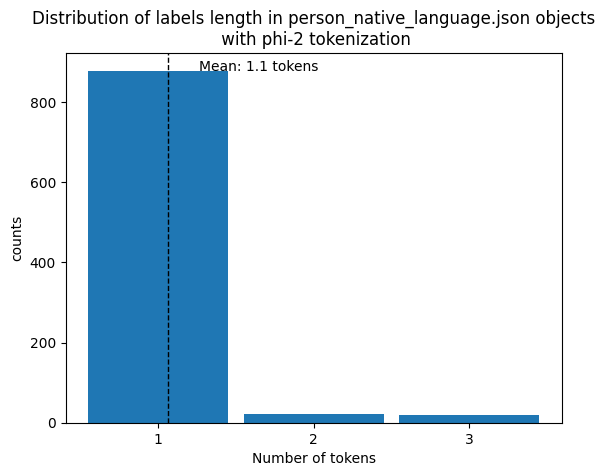

In [34]:
tokenizer = model.tokenizer

key = 'object'
labels = {}
for i, item in joint_df.iterrows():
    if item[key] not in labels:
        str_tokens = model.to_str_tokens(item[key], prepend_bos=False)
        #remove the special tokens
        # str_tokens = [tok for tok in str_tokens if tok not in [tokenizer.eos_token]]
        labels[item[key]] = str_tokens

print(f"Found {len(labels)} unique labels", labels.keys())
# augment dataset set with label lenght 
joint_df['tokenized_ent'] = joint_df[key].apply(lambda x: labels[x])

#plot the distribution of labels length
m = 10
#plot the distribution of labels length, with shifted x axis
lengths = [len(it['tokenized_ent']) for i, it in joint_df.iterrows()]
labels_len, counts = np.unique(lengths, return_counts=True)
joint_df.drop(columns=['tokenized_ent'], inplace=True)
# print(f"Test set: {len(lengths)} items for {len(labels)} unique labels")

plt.bar(labels_len, counts, width=.9, align='center')
#place ticks every 1
plt.xticks(np.arange(min(labels_len), max(labels_len)+1, 1.0))
## add mean and std
mean = np.mean(lengths)
plt.axvline(mean, color='k', linestyle='dashed', linewidth=1)
plt.text(mean + .2, np.max(counts) , f"Mean: {mean:.1f} tokens")
plt.title(f"Distribution of labels length in {json_file} objects\n with {model_name.split('/')[-1]} tokenization")
plt.xlabel("Number of tokens")
plt.ylabel("counts")
# tikzplotlib.save(f"./plots/EntityLengths_{dataset_name}_{model_name.split('/')[-1]}.tex")
plt.show()


## Filter items for which the model has no factual knowledge

In [35]:
def filter_known_facts(joint_df):
    """Filter out known facts from the joint df
    """
    if type(joint_df) == pd.DataFrame: joint_df = joint_df.to_dict(orient='records')
    for itm in tqdm(joint_df):
        obj = itm['object']
        subj = itm['subject']
        prompt = obj.join(itm['text'].split(obj)[:-1]).strip()
        #infer max five tokens
        gen = model.generate(prompt, max_new_tokens=5, temperature=0, return_type="str", verbose=False)
        gen = gen.split(prompt)[1].strip()
        itm['generated'] = gen
        itm['is_correct'] = gen.startswith(obj)
        # print(f"Prompt: {prompt}\nGenerated: {gen}\nIs correct: {itm['is_correct']}\n")
    joint_df = pd.DataFrame(joint_df)
    joint_df.head()

    ## filter out the correct ones
    known_df = joint_df[joint_df['is_correct']]
    print(f"Found {len(known_df)} correct samples on {len(joint_df)} samples in total")

    return known_df

known_df = filter_known_facts(joint_df)
# known_df = joint_df

100%|████████████████████████████████████████████████████████████████████████████████████████████| 919/919 [07:39<00:00,  2.00it/s]

Found 790 correct samples on 919 samples in total


In [36]:
joint_df.head(15)

,text,subject,object
0,Danielle Darrieux's native tongue is French,Danielle Darrieux,French
1,Thomas Joannes Stieltjes's native tongue is Dutch,Thomas Joannes Stieltjes,Dutch
2,Michel Denisot's native tongue is French,Michel Denisot,French
3,Go Hyeon-jeong's native tongue is Korean,Go Hyeon-jeong,Korean
4,Jean Gaven's native tongue is French,Jean Gaven,French
5,Symeon of Polotsk's native tongue is Russian,Symeon of Polotsk,Russian
6,Jean Galland's native tongue is French,Jean Galland,French
7,Tanya Lopert's native tongue is French,Tanya Lopert,French
8,Stefanos Stratigos's native tongue is Greek,Stefanos Stratigos,Greek
9,Gwen Stefani's native tongue is English,Gwen Stefani,English


## Augment with representations

In [37]:
layer = 3
layer = 25
layer = 31
layer = 10

method = 'average'
method = 'in_context'

def augment_with_reprs(joint_df, model, layer=0, method='after_context', batch_size=32, verbose=False):
    """
    Augment the df with representations of the entities in the text
    """
    for key in ['subject', 'object']:
        if verbose: print(f"Extracting representations for {key} with method {method}")
        joint_df["entity"] = joint_df[key] # get key into entity col 
        #drop the key column
        new_key = f"{key}_repr"
        if new_key in joint_df.columns:
            joint_df.drop(columns=[new_key], inplace=True)
        data = joint_df.to_dict(orient='records')
        repr_df = EntityReprDataset(
            data=data,
            max_length=500,
            max_ent_length=500
            )
        if method == 'average':
            repr_df.augment_with_avg_repr(model, layer=layer, batch_size=32, method='in_context', verbose=verbose)
        else:
            repr_df.augment_with_repr(model, layer=layer, batch_size=32, method=method, verbose=verbose)
        #back to pandas dataframe
        joint_df = pd.DataFrame(repr_df.data)
        # rename the columns
        joint_df.rename(columns={
            'representation': new_key,
        }, inplace=True)
        joint_df.drop(columns=['entity'], inplace=True)

    return joint_df

known_df = augment_with_reprs(known_df, model, layer=layer, method=method, batch_size=32, verbose=True)

Extracting representations for subject with method in_context


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:08<00:00,  3.08it/s]


Extracting representations for object with method in_context


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:11<00:00,  2.26it/s]


## Optionally use the linear filter

In [38]:
from processResults import get_taskVec

filter_reps = False
filter_reps = True   

normalization = True
normalization = False

filter_subject_reps = False

if filter_reps:
    path = get_taskVec(results_linear, model_name, layer=layer, with_context=with_context)
    print(f"Loading model from {str(path).split('/')[-1]}")
    linear_filter = torch.load(path)
    #cast the model to the correct type
    linear_filter = linear_filter.type(dtype).cuda()

    with torch.no_grad():
        rep_cleaner = lambda x: linear_filter(x.cuda()).detach().cpu()
        normalize = lambda x: x / torch.norm(x, p=2)
        #map the representations to the correct type
        # joint_dataset['subject_repr'] = joint_dataset['subject_repr'].apply(lambda x: linear_filter(x.cuda()).detach().cpu())
        known_df['object_repr'] = known_df['object_repr'].apply(rep_cleaner)
        if filter_subject_reps: known_df['subject_repr'] = known_df['subject_repr'].apply(rep_cleaner)

        if normalization:
            known_df['object_repr'] = known_df['object_repr'].apply(normalize)
            if filter_subject_reps: known_df['subject_repr'] = known_df['subject_repr'].apply(normalize)
    

found 12 jobs for layer 10 of phi-2 without context 
found ['LinearFilter_phi-2_l10_e10.0noContext.pth'] 
Loading model from LinearFilter_phi-2_l10_e10.0noContext.pth


In [39]:
known_df.head(5)

,text,subject,object,generated,is_correct,id,subject_repr,object_repr
0,Danielle Darrieux's native tongue is French,Danielle Darrieux,French,"French, but she has",True,0,"[tensor(-0.3926, dtype=torch.bfloat16), tensor...","[tensor(8.3750, dtype=torch.bfloat16), tensor(..."
1,Thomas Joannes Stieltjes's native tongue is Dutch,Thomas Joannes Stieltjes,Dutch,"Dutch, but he has",True,1,"[tensor(-0.1543, dtype=torch.bfloat16), tensor...","[tensor(54.2500, dtype=torch.bfloat16), tensor..."
2,Michel Denisot's native tongue is French,Michel Denisot,French,"French, but he has",True,2,"[tensor(1.6797, dtype=torch.bfloat16), tensor(...","[tensor(22.3750, dtype=torch.bfloat16), tensor..."
3,Go Hyeon-jeong's native tongue is Korean,Go Hyeon-jeong,Korean,"Korean, but she's",True,3,"[tensor(-0.3516, dtype=torch.bfloat16), tensor...","[tensor(27.1250, dtype=torch.bfloat16), tensor..."
4,Jean Gaven's native tongue is French,Jean Gaven,French,"French, but she has",True,4,"[tensor(0.0295, dtype=torch.bfloat16), tensor(...","[tensor(18.5000, dtype=torch.bfloat16), tensor..."


# Training linear model
in this scetion we train a linear model that will try to map representations of landmarks to their countries.

In [40]:
#separrate the df into train and test
from sklearn.model_selection import train_test_split
N_train = 50
test_size = (len(known_df) - N_train) / len(known_df)
train_df, test_df = train_test_split(known_df, test_size=test_size, random_state=42)

# #to list 
# train_df = train_df.to_dict(orient='records')
# test_df = test_df.to_dict(orient='records')

#test if some landmarks are in the test set
train_subjects = set([it for it in train_df['subject'] ])
test_subjects = set([it for it in test_df['subject'] ])

print("Train subjects: ", len(train_subjects))
print("Test subjects: ", len(test_subjects))
print("Common subjects: ", len(train_subjects.intersection(test_subjects)))
 

Train subjects:  50
Test subjects:  740
Common subjects:  0


In [41]:
dim = model.QK.shape[-1]
linear_model = torch.nn.Linear(dim, dim, bias=True)
#initialize the linear model with identity
linear_model.weight.data = torch.eye(dim).type(dtype)
linear_model.bias.data = torch.zeros(dim, dtype=dtype)
linear_model = linear_model.cuda()

hist = []
#freeze the model and the task vector
for param in model.parameters():
    param.requires_grad = False

Training on 2 batches of size 25
Epoch: 1, Batch: 8002, Loss: 22.0, lr: 0.1
Epoch: 201, Batch: 8402, Loss: 16.5, lr: 0.1
Epoch: 401, Batch: 8802, Loss: 12.5625, lr: 0.1
Epoch: 601, Batch: 9202, Loss: 18.875, lr: 0.1
Epoch: 801, Batch: 9602, Loss: 13.9375, lr: 0.1
Epoch: 1001, Batch: 10002, Loss: 21.0, lr: 0.1
Epoch: 1201, Batch: 10402, Loss: 15.9375, lr: 0.1
Epoch: 1401, Batch: 10802, Loss: 16.125, lr: 0.1
Epoch: 1601, Batch: 11202, Loss: 14.375, lr: 0.1
Epoch: 1801, Batch: 11602, Loss: 18.75, lr: 0.1
Epoch: 2001, Batch: 12002, Loss: 13.9375, lr: 0.05
Epoch: 2201, Batch: 12402, Loss: 16.625, lr: 0.05
Epoch: 2401, Batch: 12802, Loss: 13.4375, lr: 0.05
Epoch: 2601, Batch: 13202, Loss: 9.3125, lr: 0.05
Epoch: 2801, Batch: 13602, Loss: 17.25, lr: 0.05
Epoch: 3001, Batch: 14002, Loss: 15.75, lr: 0.05
Epoch: 3201, Batch: 14402, Loss: 16.875, lr: 0.05
Epoch: 3401, Batch: 14802, Loss: 15.5, lr: 0.05
Epoch: 3601, Batch: 15202, Loss: 18.375, lr: 0.05
Epoch: 3801, Batch: 15602, Loss: 16.875, lr: 

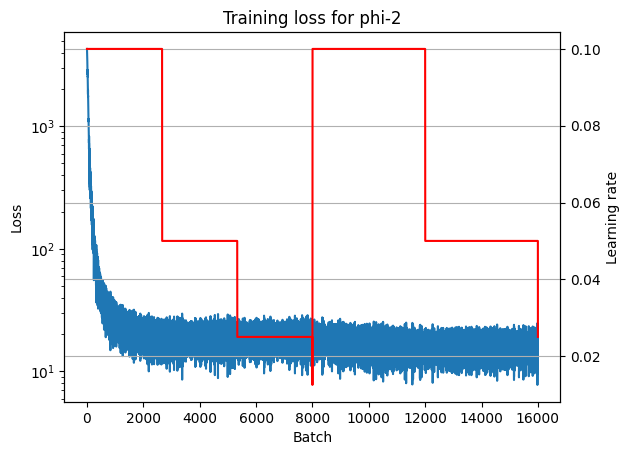

In [54]:
from torch.utils.data import DataLoader

epochs = 4000
log_every = 200
batch_per_epoch = 2
batch_size = N_train // batch_per_epoch
lr = 1e-1

grad_clip = 1e1

# optimizer
# optim = torch.optim.Adam(linear_model.parameters(), lr=lr)
optim = torch.optim.SGD(linear_model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()
# criterion = torch.nn.CosineEmbeddingLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=epochs * batch_per_epoch // 2, gamma=0.5)

#dataloader from datasets
train_loader = DataLoader(train_df.to_dict(orient='records'), batch_size=batch_size, shuffle=True)
print(f"Training on {len(train_loader)} batches of size {batch_size}")
# print(train_loader.dataset[0])

for epoch in range(epochs):
    for batch in train_loader:
        # Zero the gradients
        optim.zero_grad()
        
        subjects_reps = batch['subject_repr'].cuda()
        objects_reps = batch['object_repr'].cuda()
        y = torch.ones(objects_reps.shape[0], device="cuda")
        # print(subjects_reps.shape, objects_reps.shape)
        # Project augmented_batch representations using matrix P
        projected = linear_model(subjects_reps)
        
        # Compute the loss between projected_batch and objects_reps
        # loss = criterion(projected, objects_reps, y)
        loss = criterion(projected, objects_reps)
        loss.backward()
        # Clip the gradients
        torch.nn.utils.clip_grad_norm_(linear_model.parameters(), grad_clip)
        optim.step()
        scheduler.step()

        # Log the loss
        hist.append(
            {
                "epoch": epoch,
                "batch": len(hist),
                "loss": loss.item(),
                "lr": optim.param_groups[0]['lr']
            }
        )
    if epoch % log_every == 0:
        print(f"Epoch: {epoch+1}, Batch: {len(hist)}, Loss: {loss.item()}, lr: {optim.param_groups[0]['lr']}")

#plot the loss
#clear the plot
plt.clf()
plt.plot([it['loss'] for it in hist])
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.yscale('log')
#add athoer y axis for lr   
plt.twinx()
plt.ylabel("Learning rate")
plt.plot([it['lr'] for it in hist], color='r')

plt.grid()
plt.title(f"Training loss for {model_name}")
plt.show()


# Test 

In [43]:
fileName = get_taskVec(results, 
                       model_name, 
                       layer=layer, 
                       dataset_name=dataset_name, 
                       with_context = with_context)

TaskVec = torch.load(fileName)
#cast to dtype
TaskVec = TaskVec.to(dtype)
print("TaskVec loaded from ", fileName)

found 11 jobs for layer 10 of phi-2 without context on CoNLL2003
found ['TaskVec_phi-2_l10_e10.0.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/2de398a401fb7a6de0f27cad4c60d7ffe5ab8046a5d0df1f9d032310e9bf9418/TaskVec_phi-2_l10_e10.0.pth


In [55]:
from LabelExtractor import compute_metrics

with torch.no_grad():
    countries_from_landmarks = [
        {   'entity': item['object'],
            'subject': item['subject'],
            'object': item['object'],
            'representation': linear_model(item['subject_repr'].cuda()).detach().cpu(),
            'text': item['text'],
            'id': i,
        } for i, item in enumerate(test_df.to_dict(orient='records'))#+ train_dataset)
        ]

metrics = compute_metrics(model, 
                          TaskVec, 
                          countries_from_landmarks,
                          with_context=with_context,
                          b_size=23)
print(f"metric for generation on {json_file}: ",metrics)

100%|████████████████████████████████████████████████████████████████████████████████████████| 740/740 [00:00<00:00, 550511.70it/s]

metric for generation on person_native_language.json:  {'Partial Match': 0.8013513513513514, 'Exact Match': 0.004054054054054054, 'Chr-F': 74.34576590221809, 'Version': 1.2}


In [59]:
#remove the representations columns from countries_from_landmarks
for item in countries_from_landmarks:
    item.pop('representation', None)
countries_from_landmarks[1]

{'entity': 'Spanish',
 'subject': 'Imanol Arias',
 'object': 'Spanish',
 'text': "Imanol Arias's native tongue is Spanish",
 'id': 1,
 'inferred': 'French.'}

In [46]:
#save country_from_landmarks.json
import json
with open(f"{data_name}_{model_name}_{layer}_{method}.json", 'w') as file:
    json.dump(countries_from_landmarks, file)

In [47]:
#save metrics
data = {
    "model_name": model_name,
    "layer": layer,
    "dataset_name": dataset_name,
    "with_context": with_context,
    "metrics": metrics
}
save_path = f"./landmarks_{model_name}_{dataset_name}_{layer}_{with_context}.json"
with open(save_path, 'w') as file:
    json.dump(data, file)

In [48]:
model.cfg.n_layers

32

In [49]:
#print some examples
print(json_file)

print(f"{'Subject'.center(45)}|{'Object'.center(25)}|{'Generated'.center(25)}")
print("="*100)

for i in range(25):
    item = countries_from_landmarks[np.random.randint(len(countries_from_landmarks))]
    s = item['subject']
    o = item['object']
    print(f"{s.center(45)}|{item['object'].center(25)}|{item['inferred'].center(25)}")
    if o != item['inferred']:
        print("\t -> Fail ! ", item['text'])

person_native_language.json
                   Subject                   |          Object         |        Generated        
                   Coluche                   |          French         |         French.         
	 -> Fail !  Coluche's native tongue is French
               Oleg Skripochka               |         Russian         |         Russian.        
	 -> Fail !  Oleg Skripochka's native tongue is Russian
                  Myriam Bru                 |          French         |         French.         
	 -> Fail !  Myriam Bru's native tongue is French
                  Jean Rouch                 |          French         |         French.         
	 -> Fail !  Jean Rouch's native tongue is French
              Dominique Lapierre             |          French         |         French.         
	 -> Fail !  Dominique Lapierre's native tongue is French
                 Lydie Denier                |          French         |         French.         
	 -> Fail !  Lydie Denier

## Results

Filtered factually known associations
Landmarks:

layer 20:
 - Test size 90% (55/500) : 
    - With linear Filter: $67,8\%$ EM on Test. 
    -  No linear Filter : $67,5\%$ EM on Test. 
 - 10 / 546
   - w/o linear : 60% EM

layer 30 
 - Test size 90% (55/500) : 
    -  No linear Filter : $60.4\%$ EM on Test. 
    - With linear Filter: $61,4\%$ EM on Test. 

layer 3 
 - Test size 90% (55/500) : 
    -  No linear Filter : $45,1\%$ EM on Test. 
    - With linear Filter: $45,1\%$ EM on Test. 

# Ploting results

In [2]:
%cd ~/code/entityrepresentations/

/home/morand/code/entityrepresentations


['RelExtraction_landmarks_phi-2_in_context_1.json', 'RelExtraction_landmarks_phi-2_average_cleaned_0.json', 'RelExtraction_landmarks_phi-2_average_1.json', 'RelExtraction_landmarks_phi-2_in_context_0.json', 'RelExtraction_landmarks_phi-2_average_3.json', 'RelExtraction_landmarks_phi-2_in_context_2.json', 'RelExtraction_landmark_in_country_phi-2_in_context_cleaned_0.json', 'RelExtraction_landmark_in_country_phi-2_average_cleaned_0.json', 'RelExtraction_landmark_in_country_phi-2_average_0.json']
RelExtraction_landmarks_phi-2_in_context_1.json
RelExtraction_landmarks_phi-2_average_cleaned_0.json
RelExtraction_landmarks_phi-2_average_1.json
RelExtraction_landmarks_phi-2_in_context_0.json
RelExtraction_landmarks_phi-2_average_3.json
RelExtraction_landmarks_phi-2_in_context_2.json
RelExtraction_landmark_in_country_phi-2_in_context_cleaned_0.json
RelExtraction_landmark_in_country_phi-2_average_cleaned_0.json
RelExtraction_landmark_in_country_phi-2_average_0.json


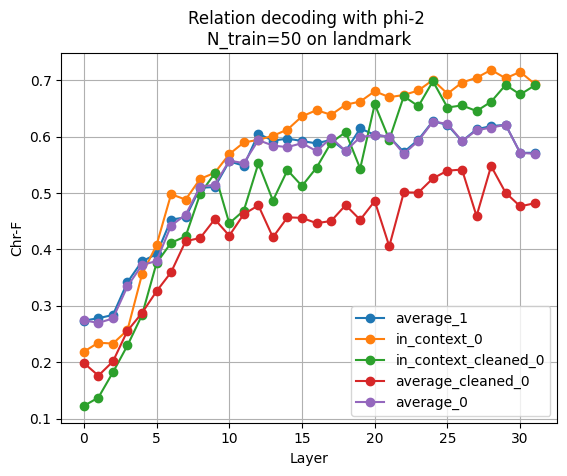

In [18]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd
import tikzplotlib

model_name = "phi-2"
dataset_name = "CoNLL2003"
data_name = "person_native_language"
data_name = "constellation"
data_name = "landmark"
filter_N_train = 200
filter_N_train = 0
filter_N_train = 50


res_files = [f for f in os.listdir() if f.startswith("RelExtraction") and f.endswith(".json") and data_name in f]
print(res_files)
results = []

for res_file in res_files:
    #load it
    print(res_file)
    with open(res_file, 'r') as file:
        data = json.load(file)

    cleaned  = data[0].get('cleaned', False)
    method = data[0].get('method', 'in_context')
    N_train = data[0].get('N_train', 10)
    layers = [d['layer'] for d in data]

    EM = [d['metrics']['Exact Match'] for d in data]
    chrf = [d['metrics']['Chr-F']/100 for d in data]
    partial = [d['metrics']['Partial Match'] for d in data]
    label = res_file.split('.json')[0].split(model_name + "_")[-1]
    results.append(
        {
            "method": method,
            "N_train": N_train,
            "cleaned": cleaned,
            "label": label,
            "file": res_file,
            "data" : data,
        }
    )
    if not filter_N_train or N_train == filter_N_train:
        # plt.plot(EM, 'o-', label=label)
        plt.plot(chrf, 'o-', label=label)
        # plt.plot(partial, 'o-', label=label)
    plt.title(f"Relation decoding with {model_name} \n{f'N_train={N_train}' if N_train else ''} on {data_name}")
results = pd.DataFrame(results)
plt.legend()
plt.grid()
# plt.xticks(np.arange(len(EM)), layers)
plt.xlabel("Layer")
# plt.ylabel("Exact Match")
plt.ylabel("Chr-F")
tikzplotlib.save(f"./plots/RelExtraction_{data_name}_{model_name}.tex")   

In [52]:
results.head()

,method,N_train,cleaned,label,file,data
0,average,50,False,average_0,RelExtraction_person_native_language_phi-2_ave...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
1,in_context,50,False,in_context_1,RelExtraction_person_native_language_phi-2_in_...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
2,average,50,True,average_cleaned_0,RelExtraction_person_native_language_phi-2_ave...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
3,in_context,50,True,in_context_cleaned_0,RelExtraction_person_native_language_phi-2_in_...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."
4,in_context,50,True,in_context_cleaned_1,RelExtraction_person_native_language_phi-2_in_...,"[{'model_name': 'phi-2', 'layer': 0, 'N_train'..."


In [8]:
import numpy as np
layer = 30

method = 'in_context'
cleaned = True

filtered_data = results[(results['method']==method) & (results['cleaned']==cleaned) & (results['N_train']==filter_N_train)]
#filter out the layer
data = [d for d in filtered_data["data"].values[-1] if d['layer'] == layer][0]

#print metrics
print(filtered_data['file'].values)
print(f"data for layer {layer} and method {method} on {data_name}")
print(data['metrics'])

#print infernce 
inference = data['inference']
columns = ['subject', 'object', 'inferred']
print(f"{'Subject'.center(45)}|{'Object'.center(25)}|{'Inferred'.center(25)}")
print("="*100)

for i in range(30):
    item = inference[np.random.randint(len(inference))]
    s = item['subject']
    o = item['object']
    print(f"{s.center(45)}|{o.center(25)}|{item['inferred'].center(25)}")

['RelExtraction_person_native_language_phi-2_in_context_cleaned_0.json']
data for layer 30 and method in_context on person
{'Partial Match': 0.9054794520547945, 'Exact Match': 0.9027397260273973, 'Chr-F': 89.11429421466515, 'Version': 1.2}
                   Subject                   |          Object         |         Inferred        
              Julien Boisselier              |          French         |          French         
                Sacha Briquet                |          French         |          French         
             Jean-Louis Barrault             |          French         |          French         
                 George Sand                 |          French         |          French         
               Gustave Geffroy               |          French         |          French         
                 Michel Robin                |          French         |          French         
                Dmitry Puchkov               |         Russian         |  